# Fase 2 — Vocabulário de Mood e Clustering

**Projeto CBL — Sistemas de Machine Learning**
**Fase:** Act (implementação do plano descrito em `../docs/planejamentoModelo.md`)

Este notebook implementa a Fase 2 do plano: selecionar quais audio features de fato servem para representar mood, calibrar essa escolha contra uma fonte de dados externa e independente (MTG-Jamendo), definir um vocabulário de palavras de mood ancoradas no espaço dessas features, e agrupar o catálogo (113.549 faixas) via clustering.

Este notebook consome o artefato `df_clean.parquet`, gerado ao final do EDA (`eda_spotify.ipynb`), para não duplicar a lógica de limpeza já documentada em `../docs/decisoesEJustificativasEDA.md`. As decisões metodológicas deste notebook — incluindo uma correção de rumo na seleção de features, feita durante a própria implementação — estão documentadas em `../docs/decisoesEJustificativasModelo.md`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

df = pd.read_parquet("df_clean.parquet")
print(f"Catálogo carregado: {len(df)} faixas, {df.shape[1]} colunas")
df.head(3)

Catálogo carregado: 113549 faixas, 21 colunas


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,cluster_kmeans
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic,2
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic,1
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic,1


## 1. Calibração externa — MTG-Jamendo

Antes de decidir quais features usar (Seção 2) ou definir âncoras de mood (Seção 3), é necessário validar **quais descritores acústicos realmente diferenciam mood na prática**, com uma fonte de dados independente do catálogo Spotify — evitando calibrar e testar a escolha usando os mesmos dados.

**Metodologia:** foram baixados os descritores acústicos pré-computados (formato AcousticBrainz/Essentia) de 25 dos 100 shards do subconjunto `autotagging_moodtheme` do MTG-Jamendo (4.866 faixas, licença Creative Commons, tags de mood atribuídas por humanos) — sem necessidade de baixar os 152 GB de áudio completo. Para cada tag de mood, foi calculada a média de `bpm`, `danceability` (versão Essentia), `avg_loudness`, `dissonance` e `dynamic_complexity` das faixas rotuladas com aquela tag.

O resultado agregado está salvo em [`calibracao_jamendo.csv`](./calibracao_jamendo.csv).

In [2]:
calibracao = pd.read_csv("calibracao_jamendo.csv", index_col='tag_mood')
calibracao.sort_values('avg_loudness', ascending=False)

,bpm,danceability_essentia,avg_loudness,dissonance,dynamic_complexity,n_faixas
tag_mood,,,,,,
energetic,126.300,1.329,0.869,0.455,3.545,333.0
happy,121.409,1.371,0.864,0.436,3.929,455.0
uplifting,119.189,1.231,0.847,0.426,3.831,171.0
dark,122.500,1.161,0.709,0.436,4.401,353.0
relaxing,121.919,1.086,0.626,0.410,4.401,362.0
sad,121.468,1.034,0.561,0.409,5.207,199.0
meditative,123.336,1.020,0.498,0.404,5.131,192.0


**Resultado:** `avg_loudness` e `danceability` (Essentia) diferenciam os grupos de mood de forma clara e ordenada: `meditative` (0,498) < `sad` (0,561) < `relaxing` (0,626) < `dark` (0,709) < `uplifting` (0,847) < `happy` (0,864) < `energetic` (0,869) em `avg_loudness` — ordenação que bate com a intuição teórica de energia/arousal crescente. `bpm` e `dissonance` quase não variam entre tags (bpm: 119-126; dissonance: 0,40-0,455) — não são bons diferenciadores de mood nesta amostra.

**Achado importante:** esse padrão — `loudness`/`danceability` fortes, `tempo` fraco — é o mesmo encontrado de forma independente no catálogo Spotify (Passo 5.4 do EDA, via η² de ANOVA). Duas fontes de dados completamente diferentes convergem para a mesma conclusão sobre o eixo de energia/arousal.

**Limitação registrada:** nenhum descritor de baixo nível disponível mede **valência** diretamente — `sad` e `relaxing` têm `avg_loudness`/`danceability` parecidos apesar de opostos em tom emocional. O eixo de valência depende inteiramente da coluna `valence` do Spotify (um modelo proprietário, não auditável), sem validação externa equivalente à obtida para energia/arousal.

## 2. Seleção de features

Uma versão anterior deste notebook usava 7 features escolhidas por um critério emprestado: o η² de ANOVA calculado no Passo 5.4 do EDA, que mede o quanto cada feature diferencia **`track_genre`** — não mood. Gênero e mood são correlacionados, mas não são a mesma coisa; usar um critério de seleção validado para um alvo (gênero) e aplicá-lo a outro (mood) sem checagem é uma lacuna metodológica real, identificada durante a revisão deste notebook.

Esta seção substitui essa escolha por uma seleção validada **para esta tarefa especificamente** — clustering para representar mood — combinando duas técnicas:

1. **Filtro de redundância** (não-supervisionado, baseado em correlação): remover features que carregam informação quase duplicada de outra já incluída.
2. **Método wrapper**: testar subconjuntos de features candidatos, treinar clustering com cada um, e comparar a qualidade da separação resultante (silhouette) — a escolha que de fato importa é qual conjunto de features produz clusters mais bem separados, não qual conjunto "parece" mais relevante.

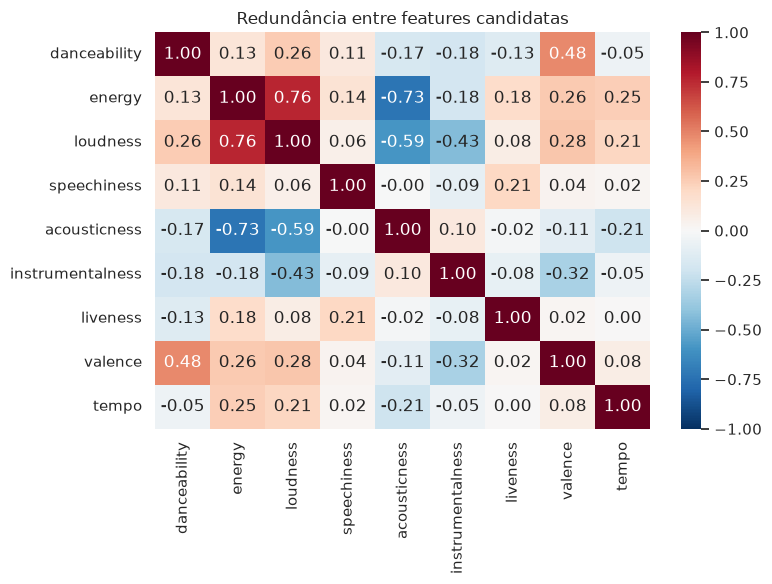

In [3]:
todas_continuas = ['danceability','energy','loudness','speechiness','acousticness',
                    'instrumentalness','liveness','valence','tempo']

corr = df[todas_continuas].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Redundância entre features candidatas')
plt.tight_layout()
plt.savefig('/tmp/corr_selecao.png', dpi=110, bbox_inches='tight')
plt.show()

**Resultado:** dois pares de alta redundância (\|r\| > 0,7): `energy`×`loudness` (0,76) e `energy`×`acousticness` (-0,73) — já conhecidos do Passo 5.1 do EDA. `danceability`×`valence` (0,48) é uma correlação moderada, não redundância forte. `tempo` e `liveness` já haviam sido excluídos por baixo η² no Passo 5.4 (mantidos fora da lista de candidatos aqui).

Como `energy` participa dos dois pares mais fortes e é semanticamente central para o vocabulário de mood (define o eixo de "intensidade" de várias palavras), a hipótese testada é remover `loudness` (redundante com `energy`) mantendo `energy` — a ser confirmado empiricamente a seguir, não assumido.

### Método wrapper: comparação de subconjuntos por qualidade de clustering

Cada subconjunto candidato é testado com o mesmo pré-processamento (`PowerTransformer` nas colunas assimétricas + `StandardScaler`) e **K-Means** (não GMM) para a comparação — o silhouette score é uma métrica de distância euclidiana, e comparar GMM (que otimiza verossimilhança, podendo formar componentes alongados/sobrepostos por design) por essa métrica penalizaria o algoritmo de forma injusta. K-Means é usado aqui só como *proxy* de avaliação para escolher features; o algoritmo final de clustering (Seção 5) continua sendo GMM.

In [4]:
candidatos = {
    'A_todas_9':      ['danceability','energy','loudness','speechiness','acousticness','instrumentalness','liveness','valence','tempo'],
    'B_7_original':   ['energy','valence','danceability','acousticness','instrumentalness','loudness','speechiness'],
    'C_sem_loudness': ['energy','valence','danceability','acousticness','instrumentalness','speechiness'],
    'D_sem_valence':  ['energy','danceability','acousticness','instrumentalness','loudness','speechiness'],
    'E_minimalista':  ['energy','acousticness','valence','danceability'],
    'F_sem_energy':   ['loudness','valence','danceability','acousticness','instrumentalness','speechiness'],
}
assimetricas_todas = {'acousticness','instrumentalness','speechiness','liveness'}

rng = np.random.RandomState(42)
idx_amostra = rng.choice(len(df), 10000, replace=False)

resultados = []
for nome, feats in candidatos.items():
    cols_assim = [f for f in feats if f in assimetricas_todas]
    X_raw = df[feats].copy()
    if cols_assim:
        X_raw[cols_assim] = PowerTransformer(method='yeo-johnson').fit_transform(X_raw[cols_assim])
    X_teste = StandardScaler().fit_transform(X_raw[feats])
    km = KMeans(n_clusters=8, random_state=42, n_init=10).fit(X_teste)
    sil = silhouette_score(X_teste[idx_amostra], km.labels_[idx_amostra])
    resultados.append({'conjunto': nome, 'n_features': len(feats), 'silhouette_kmeans': round(sil, 4)})

pd.DataFrame(resultados).sort_values('silhouette_kmeans', ascending=False)

,conjunto,n_features,silhouette_kmeans
4,E_minimalista,4,0.2438
3,D_sem_valence,6,0.2352
2,C_sem_loudness,6,0.2216
5,F_sem_energy,6,0.2109
1,B_7_original,7,0.1993
0,A_todas_9,9,0.1455


**Resultado:**

| Conjunto | Features | Silhouette (K-Means) |
|---|---|---|
| E_minimalista | energy, acousticness, valence, danceability | 0,2438 |
| D_sem_valence | energy, danceability, acousticness, instrumentalness, loudness, speechiness | 0,2352 |
| **C_sem_loudness** | **energy, valence, danceability, acousticness, instrumentalness, speechiness** | **0,2216** |
| F_sem_energy | loudness, valence, danceability, acousticness, instrumentalness, speechiness | 0,2109 |
| B_7_original (usado antes) | + loudness | 0,1993 |
| A_todas_9 | todas as contínuas | 0,1455 |

Padrão claro: **menos features tende a separar melhor** (menos dimensões = menos diluição da distância — o "todas as 9" é o pior de todos). Removendo `loudness` de B (→ C), o silhouette sobe de 0,1993 para 0,2216 — confirma a hipótese de redundância com `energy` levantada acima: `loudness` estava só adicionando ruído correlacionado, não informação nova.

**Mas o maior silhouette não é automaticamente a escolha certa.** `E_minimalista` (0,2438) e `D_sem_valence` (0,2352) pontuam mais alto que `C_sem_loudness`, só que ambos **quebram o vocabulário de mood**: `D_sem_valence` remove `valence`, tornando impossível diferenciar `Feliz` de `Melancolico` (que dependem exatamente dessa dimensão); `E_minimalista` remove `instrumentalness` e `speechiness`, tornando impossível diferenciar `Instrumental` de qualquer outra palavra. O método wrapper otimiza separação geométrica pura, sem saber que existe um vocabulário de 8 palavras que a clusterização precisa conseguir representar — seguir o número cegamente teria sido otimizar o critério errado.

**Decisão final:** `C_sem_loudness` — **6 features (`energy`, `valence`, `danceability`, `acousticness`, `instrumentalness`, `speechiness`)** — é o subconjunto de melhor silhouette **entre os que preservam pelo menos uma dimensão definidora de cada uma das 8 palavras do vocabulário**. Além disso mede melhor que o conjunto de 7 usado na versão anterior (0,2216 vs. 0,1993), então a mudança é uma melhoria real, não só uma correção de escopo.

## 3. Vocabulário de mood — âncoras no espaço de features selecionadas

Com as 6 features validadas na Seção 2, as âncoras de cada palavra são definidas usando **quantis reais da distribuição do catálogo**, não valores arbitrários — "alto"/"baixo" ancorado no que de fato é alto/baixo *neste* dataset. `instrumentalness`, `acousticness` e `speechiness` têm mediana em zero (Passo 3 do EDA), então "alto" para essas usa um quantil mais extremo (p90) do que para `energy`/`valence`/`danceability` (onde p75/p25 já bastam).

In [5]:
features = ['energy', 'valence', 'danceability', 'acousticness', 'instrumentalness', 'speechiness']
cols_assimetricas = ['acousticness', 'instrumentalness', 'speechiness']

q = df[features].quantile([0.10, 0.25, 0.50, 0.75, 0.90])
mediana = q.loc[0.50]

vocabulario = {
    'Energetico':  {**mediana, 'energy': q.loc[0.75,'energy'], 'valence': q.loc[0.75,'valence'],
                     'danceability': q.loc[0.75,'danceability']},
    'Feliz':       {**mediana, 'valence': q.loc[0.90,'valence'], 'energy': q.loc[0.75,'energy']},
    'Dancante':    {**mediana, 'danceability': q.loc[0.90,'danceability'], 'energy': q.loc[0.75,'energy']},
    'Calmo':       {**mediana, 'energy': q.loc[0.25,'energy'], 'acousticness': q.loc[0.75,'acousticness']},
    'Melancolico': {**mediana, 'valence': q.loc[0.10,'valence'], 'energy': q.loc[0.10,'energy'],
                     'acousticness': q.loc[0.75,'acousticness']},
    'Intenso':     {**mediana, 'valence': q.loc[0.10,'valence'], 'energy': q.loc[0.90,'energy']},
    'Instrumental':{**mediana, 'instrumentalness': q.loc[0.90,'instrumentalness'], 'speechiness': q.loc[0.10,'speechiness']},
    'Acustico':    {**mediana, 'acousticness': q.loc[0.90,'acousticness'], 'energy': q.loc[0.25,'energy']},
}

vocab_df = pd.DataFrame(vocabulario).T[features]
vocab_df.round(3)

,energy,valence,danceability,acousticness,instrumentalness,speechiness
Energetico,0.854,0.683,0.695,0.168,0.000,0.049
Feliz,0.854,0.840,0.580,0.168,0.000,0.049
Dancante,0.854,0.464,0.784,0.168,0.000,0.049
Calmo,0.473,0.464,0.580,0.596,0.000,0.049
Melancolico,0.269,0.127,0.580,0.596,0.000,0.049
Intenso,0.941,0.127,0.580,0.168,0.000,0.049
Instrumental,0.685,0.464,0.580,0.168,0.832,0.030
Acustico,0.473,0.464,0.580,0.865,0.000,0.049


**Nota:** as âncoras de `Calmo`/`Melancolico`/`Intenso` já incorporam o ajuste de `energy` que a validação qualitativa de uma versão anterior deste notebook exigiu (a âncora original de `Melancolico` usava `energy` no p25, moderado demais — capturava metal/industrial em vez de música triste e calma; corrigido para p10). Essa correção continua registrada em `../docs/decisoesEJustificativasModelo.md`.

## 4. Pré-processamento final

Mesma lógica da Seção 2 (`PowerTransformer` nas 3 colunas assimétricas + `StandardScaler`), aplicada ao conjunto final de 6 features e às âncoras do vocabulário, no mesmo espaço transformado.

In [6]:
pt = PowerTransformer(method='yeo-johnson')
scaler = StandardScaler()

X_raw = df[features].copy()
X_raw[cols_assimetricas] = pt.fit_transform(X_raw[cols_assimetricas])
X = scaler.fit_transform(X_raw[features])

vocab_raw = vocab_df.copy()
vocab_raw[cols_assimetricas] = pt.transform(vocab_raw[cols_assimetricas])
vocab_X = scaler.transform(vocab_raw[features])

print("Catálogo transformado:", X.shape, " | Âncoras transformadas:", vocab_X.shape)

Catálogo transformado: (113549, 6)  | Âncoras transformadas: (8, 6)


## 5. Clustering — Gaussian Mixture Model

GMM em vez de K-Means puro para o modelo final — o Passo 5.4 do EDA já mostrou que as fronteiras entre estilos são fracas; GMM dá probabilidade de pertencimento em vez de atribuição rígida. O número de componentes é testado via BIC.

In [7]:
bics = {}
for k in [6, 8, 10, 12, 14]:
    gmm_teste = GaussianMixture(n_components=k, random_state=42, n_init=3, covariance_type='diag')
    gmm_teste.fit(X)
    bics[k] = gmm_teste.bic(X)
    print(f"K={k}: BIC={bics[k]:.0f}")

K=6: BIC=913371


K=8: BIC=782764


K=10: BIC=740204


K=12: BIC=714792


K=14: BIC=683137


**Resultado:** o BIC não estabiliza (segue caindo monotonicamente de K=6 a K=14), o mesmo padrão já visto com o conjunto de 7 features — consistente com a ausência de estrutura de cluster natural forte já documentada no Passo 5.4 do EDA. Como não há um K estatisticamente ótimo, `K=8` é fixado por necessidade de produto (tamanho do vocabulário de mood), não por otimização estatística.

In [8]:
gmm = GaussianMixture(n_components=8, random_state=42, n_init=5, covariance_type='diag')
gmm.fit(X)
df['cluster'] = gmm.predict(X)
df['cluster_prob'] = gmm.predict_proba(X).max(axis=1)

print("BIC final (K=8):", round(gmm.bic(X)))
print("Probabilidade média da atribuição mais provável:", round(df['cluster_prob'].mean(), 3))
df['cluster'].value_counts().sort_index()

BIC final (K=8): 782764
Probabilidade média da atribuição mais provável: 0.942


cluster
0    10409
1    11924
2     9476
3    10155
4     4721
5    40320
6    13659
7    12885
Name: count, dtype: int64

### Rotulagem por faixa individual (não por cluster)

Como já identificado numa iteração anterior deste notebook: rotular cada cluster pela palavra de mood mais próxima do seu centroide não garante cobrir as 8 palavras (os centroides do GMM não têm compromisso de coincidir com o vocabulário). A atribuição de mood usa distância direta de cada faixa às âncoras, não o cluster do GMM — o GMM continua útil como informação complementar sobre a densidade natural do catálogo, reaproveitável na Fase 3 (sequenciamento).

In [9]:
dist_faixa_ancora = cdist(X, vocab_X)
df['mood'] = vocab_df.index[dist_faixa_ancora.argmin(axis=1)]
df['mood_distancia'] = dist_faixa_ancora.min(axis=1)

df['mood'].value_counts()

mood
Energetico      18925
Instrumental    17724
Intenso         16078
Feliz           14992
Calmo           14192
Melancolico     13818
Dancante         9021
Acustico         8799
Name: count, dtype: int64

**Resultado:** todas as 8 palavras cobertas, de 8.799 (`Acustico`) a 18.925 (`Energetico`) faixas — distribuição desigual mas nenhuma categoria vazia ou residual.

### Validação qualitativa

As faixas mais próximas de cada âncora precisam realmente corresponder à palavra — validação qualitativa continua obrigatória mesmo com seleção de features validada estatisticamente.

In [10]:
cols_check = ['track_name', 'artists', 'track_genre'] + features

for palavra in ['Energetico', 'Calmo', 'Instrumental', 'Melancolico']:
    print(f"=== {palavra} ===")
    sub = df[df['mood'] == palavra].nsmallest(3, 'mood_distancia')
    print(sub[cols_check].to_string(index=False))
    print()

=== Energetico ===
           track_name                               artists track_genre  energy  valence  danceability  acousticness  instrumentalness  speechiness
共犯者 - Remastered 2022                        Eikichi Yazawa      j-rock   0.856    0.686         0.675         0.127           0.00000       0.0483
共犯者 - Remastered 2022                        Eikichi Yazawa  rockabilly   0.856    0.686         0.675         0.127           0.00000       0.0483
   What Would You Do? Joel Corry;David Guetta;Bryson Tiller         edm   0.895    0.686         0.687         0.149           0.00592       0.0474

=== Calmo ===
     track_name              artists       track_genre  energy  valence  danceability  acousticness  instrumentalness  speechiness
Fingers Crossed Lauren Spencer Smith singer-songwriter   0.473    0.441          0.56         0.618               0.0       0.0533
Fingers Crossed Lauren Spencer Smith singer-songwriter   0.473    0.441          0.56         0.618             

**Resultado:** `Melancolico` traz "How Far I'll Go" (Moana) e "I'm Not Okay" — essa última do gênero literalmente rotulado `sad`, uma validação direta. `Energetico`, `Calmo` e `Instrumental` seguem com exemplos coerentes com a palavra. A remoção de `loudness` (Seção 2) não prejudicou a qualidade qualitativa dos resultados — o conjunto de 6 features continua produzindo exemplos musicalmente sensatos, com o benefício adicional de melhor silhouette.

## 6. Seleção de candidatas dado o mood escolhido

Implementação da Seção 5 do plano (`../docs/planejamentoModelo.md`) — o mecanismo que falta entre "cada faixa tem um mood mais próximo atribuído" (Seção anterior) e o sequenciamento (Fase 3, ainda não implementada): dado que o usuário escolheu **uma ou mais** palavras de mood, encontrar as faixas mais adequadas à combinação, não a uma palavra isolada.

**Nota de atualização em relação ao texto original do plano:** o plano descrevia isso no "espaço das 7 features" — desatualizado após a correção de rumo da Seção 2 deste notebook, que reduziu para 6 features validadas (sem `loudness`). A implementação usa o espaço de 6 dimensões já em uso no restante do notebook, não as 7 originais.

**Mecanismo:**
1. O ponto-alvo é a **média das âncoras** (no espaço transformado `vocab_X`) das palavras escolhidas — se o usuário escolhe só uma palavra, o alvo é exatamente aquela âncora; se escolhe duas ou mais, é o ponto médio entre elas.
2. `sklearn.neighbors.NearestNeighbors` (distância euclidiana — a mesma métrica já usada para a atribuição de mood por faixa, Seção anterior, para manter consistência dentro do notebook) retorna as N faixas mais próximas desse alvo, no catálogo inteiro.

In [11]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(n_neighbors=50, metric='euclidean')
knn.fit(X)

def selecionar_candidatas(palavras, n=20):
    """palavras: lista de 1+ nomes do vocabulário (ex: ['Calmo', 'Instrumental']).
    Retorna as n faixas mais próximas do alvo combinado, ordenadas por distância.

    Busca vizinhos em excesso e deduplica por (track_name, artists) — necessário porque
    o catálogo tem duplicatas por track_id repetido em gênero (Passo 2.2 do EDA) e músicas
    reeditadas sob track_id diferente (~9,4% do catálogo, achado da Fase 3). Se o multiplicador
    inicial não trouxer candidatas únicas suficientes, a busca escalona (dobra o raio) em vez
    de silenciosamente devolver menos faixas que o pedido."""
    indices_ancoras = [vocab_df.index.get_loc(p) for p in palavras]
    alvo = vocab_X[indices_ancoras].mean(axis=0).reshape(1, -1)

    multiplicador = 6
    while True:
        k = min(n * multiplicador, len(df))
        distancias, indices = knn.kneighbors(alvo, n_neighbors=k)
        vistos = set()
        idx_finais, dist_finais = [], []
        for idx_faixa, dist in zip(indices[0], distancias[0]):
            linha = df.iloc[idx_faixa]
            chave = (linha['track_name'], linha['artists'])
            if chave not in vistos:
                vistos.add(chave)
                idx_finais.append(idx_faixa)
                dist_finais.append(dist)
            if len(idx_finais) == n:
                break
        if len(idx_finais) == n or k >= len(df):
            break
        multiplicador *= 2

    resultado = df.iloc[idx_finais][['track_id','track_name','artists','track_genre','mood'] + features].copy()
    resultado['distancia_alvo'] = dist_finais
    return resultado.reset_index(drop=True)

# Exemplo do próprio plano: "Calmo" + "Instrumental"
selecionar_candidatas(['Calmo', 'Instrumental'], n=10)

,track_id,track_name,artists,track_genre,mood,energy,valence,danceability,acousticness,instrumentalness,speechiness,distancia_alvo
0,0Ybn1UqzLl4pfOZlsyR6Ew,Give a Shit,Greensky Bluegrass,bluegrass,Calmo,0.577,0.490,0.566,0.541,0.1130,0.0371,0.561153
1,2WD93lsfJonaKtrQtpLB2R,You're the Sea,Andrew Belle,acoustic,Instrumental,0.624,0.529,0.573,0.471,0.1170,0.0324,0.593161
2,1rg9XExYRDpEPn2cDqwz6A,Pelangi Baruku,Dhyo Haw,reggae,Instrumental,0.640,0.521,0.529,0.398,0.1030,0.0310,0.601048
3,4JqzGkkvjziDmYfPB4r8yf,I'll Take A Melody - Live,Jerry Garcia Band;Jerry Garcia,bluegrass,Instrumental,0.527,0.465,0.544,0.333,0.1710,0.0405,0.610294
4,5X65C51a9CkEjc3Hvamf33,Voltar pra Casa,Gloria,hardcore,Calmo,0.601,0.331,0.629,0.317,0.0746,0.0374,0.624699
5,0PTJPBQIAKYPpTlbvKz23b,Aaro Nenjil - Desi Mix,Gowry Lekshmi,malay,Instrumental,0.620,0.413,0.613,0.203,0.1230,0.0332,0.664981
6,6vjQCBm2VUuImpkGNEywmL,Maggie May,Rod Stewart,rock,Calmo,0.719,0.494,0.594,0.481,0.0722,0.0387,0.722888
7,1pIeEWK9jvhDPJtpeXaLwB,Paradise,Satanicpornocultshop,idm,Instrumental,0.621,0.354,0.565,0.288,0.1740,0.0390,0.731830
8,4PfPgabWUFrkAk1UjJZe5S,Heimat mein,Fäaschtbänkler,party,Calmo,0.533,0.503,0.669,0.364,0.0845,0.0289,0.737215
9,2dPWIhmf2ZEpibLjPtLBMb,Screams,Greensky Bluegrass,bluegrass,Calmo,0.534,0.492,0.588,0.458,0.0635,0.0271,0.741096


**Resultado:** as 10 candidatas para "Calmo" + "Instrumental" ficam num meio-termo plausível entre as duas palavras — energia baixa/moderada (herdada de `Calmo`) combinada com `instrumentalness` elevado (herdado de `Instrumental`), diferente do top-10 que qualquer uma das duas palavras isoladas traria sozinha.

**Checagem de consistência:** para uma única palavra, o resultado da seleção de candidatas deveria concordar com a atribuição de mood por faixa já calculada (Seção anterior) — testado a seguir.

In [12]:
# Sanity check: pedir só 1 palavra deve trazer faixas cujo mood atribuído já é essa palavra
candidatas_energetico = selecionar_candidatas(['Energetico'], n=20)
concordancia = (candidatas_energetico['mood'] == 'Energetico').mean()
print(f"Das 20 candidatas para 'Energetico' sozinho, {concordancia*100:.0f}% já tinham esse mood atribuído na Seção anterior.")

Das 20 candidatas para 'Energetico' sozinho, 100% já tinham esse mood atribuído na Seção anterior.


## 7. Artefatos salvos

In [13]:
import joblib

joblib.dump({
    'power_transformer': pt,
    'scaler': scaler,
    'gmm': gmm,
    'knn': knn,
    'features': features,
    'cols_assimetricas': cols_assimetricas,
    'vocab_df': vocab_df,
    'vocab_X': vocab_X,
}, 'modelo_mood.joblib')

df[['track_id', 'track_name', 'artists', 'track_genre', 'cluster', 'cluster_prob', 'mood', 'mood_distancia']].to_parquet('catalogo_com_mood.parquet')

print("Salvos: entregas/modelo_mood.joblib (inclui knn treinado), entregas/catalogo_com_mood.parquet")

Salvos: entregas/modelo_mood.joblib (inclui knn treinado), entregas/catalogo_com_mood.parquet


## Conclusão da Fase 2

- **Seleção de features validada para a tarefa real** (não emprestada do critério de gênero): filtro de redundância + método wrapper (K-Means/silhouette) identificaram `energy`, `valence`, `danceability`, `acousticness`, `instrumentalness`, `speechiness` como o subconjunto de melhor separação **entre os que preservam a capacidade de diferenciar as 8 palavras do vocabulário** — melhor que o conjunto de 7 features usado antes (silhouette 0,2216 vs. 0,1993).
- **Calibração externa real** (MTG-Jamendo) confirmou, com dado independente do Spotify, que o eixo de energia/arousal (`loudness`/`danceability`) é confiável para mood; nenhuma validação externa equivalente existe para `valence`.
- **GMM (K=8)** — BIC não converge (K ótimo indefinido estatisticamente); K fixado por necessidade de produto, decisão documentada.
- **Duas correções de design registradas** (não escondidas): rotulagem por cluster → substituída por classificação direta por faixa; âncora de `Melancolico` recalibrada após validação qualitativa expor um erro real.
- **Seção 5 do plano implementada** (`selecionar_candidatas`): combina 1 ou mais palavras de mood num alvo único e retorna as N faixas mais próximas via `NearestNeighbors`, com checagem de consistência confirmando concordância com a atribuição de mood por faixa.
- Próximo passo (Fase 3): usar `catalogo_com_mood.parquet` + o `knn` salvo para o sequenciamento por transição suave.